# 8/31 blue/orange/red design plates -- raw fluorescence, plus OD600 dilution checks

Nine excitation/emission scans plus two OD600 endpoint reads (`##BLOCKS= 11` in the raw export).
Unlike earlier runs in this series, this run's two OD600 blocks don't share well
positions with the fluorescence plate's layout below (`4x diluted 200uL` spans rows A-C x cols
1-12; `4x diluted 100 uL` spans rows C-D x cols 1-8 -- both look like serial-dilution QC reads of
whole cultures, not a per-design row/column match to the B/C/D fluorescence layout). With no
established well-to-well correspondence, they're plotted separately as raw plate-view heatmaps (a
dilution/culture-density check) at the end of this notebook, rather than used to normalize any
spectrum -- so all fluorescence below is
the raw instrument reading (a.u.), comparable *within* a plate but not OD-corrected.

## Reading the raw export

Same SoftMax Pro UTF-16 text export format as prior days. `20260831_jeb_zz_FP_raw_well_data.csv`
is already a tidy per-(plate, well, wavelength) export, so it's loaded as-is below rather than
re-parsed from the `.xls`.

## Well layout (fluorescence plates)

Every one of the nine spectral scans shares row B as a reference row of controls; each scan
additionally reads either row C (3 wells) or row D (7 wells) of new designs, per the plate map
provided for this run:

| Row | col 1 | col 2 | col 3 | col 4 | col 5 | col 6 | col 7 |
|---|---|---|---|---|---|---|---|
| **B** (every scan) | EGFP (clone D2) | EBFP (clone A1) | mOrange (clone E2) | pUC (empty vector ctrl) | PBS (blank) | | |
| **C** (`p1: Em480`, `p2: Ex340` only) | design B1 | design C1 | design D1 | | | | |
| **D** (the other 7 scans) | design E1 | design F1 | design G1 | design H1 | design A2 | design B2 | design C2 |

Wells C1 (design "B1") and D4 (design "H1") were marked in bold in the layout as given to this
notebook; no further meaning is assumed here and they're plotted identically to their neighbors.
Design names (B1, C1, ... H1, A2, B2, C2) are this run's own candidate IDs -- unrelated to, and
sometimes coinciding with, the well positions they happen to sit in (e.g. design "B1" sits in well
C1, not B1).

## The nine windows

Plate name encodes the fixed channel directly -- `p#: Em480` means an **excitation sweep** with
emission fixed at 480 nm; `p#: Ex340` means an **emission sweep** with excitation fixed at 340 nm
-- confirmed against each block's own `sweep_type` / fixed-wavelength header fields in the raw
export.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000/650/490 px panel really is that.
get_ipython().run_line_magic('config', 'InlineBackend.print_figure_kwargs = {"bbox_inches": None}')

import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

import arcadia_pycolor as apc

FONTS = "../../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: shared font dir not found -- run dataset_pipeline/fetch_arcadia_fonts.py, "
          "figures will render in a substitute font in the meantime.")

PX = 1 / 72          # one style-guide pixel, in inches
FLOAT = 650          # single-column panel width, px
PANEL_HEIGHT = FLOAT * 2 / 3   # 3:2 width:height

DATA_CSV = Path("20260831_jeb_zz_FP_raw_well_data.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
raw = pd.read_csv(DATA_CSV)
print(raw.shape)
raw.head()

(1324, 8)


,time,plate_name,well_position,temperature_c,value,row_label,column_label,wavelength
0,NaN,4x diluted 200uL,A1,22.6,0.9760,A,1,600
1,NaN,4x diluted 200uL,A2,22.6,1.0004,A,2,600
2,NaN,4x diluted 200uL,A3,22.6,1.0394,A,3,600
3,NaN,4x diluted 200uL,A4,22.6,1.0221,A,4,600
4,NaN,4x diluted 200uL,A5,22.6,1.0515,A,5,600


In [3]:
# Sanity checks on the assumptions the rest of this notebook relies on.
assert raw.value.min() > 0, "expected strictly positive readings (required for the log y-axis below)"

SPECTRAL_PLATES = [p for p in raw.plate_name.unique() if not p.startswith("4x diluted")]
OD_PLATES = [p for p in raw.plate_name.unique() if p.startswith("4x diluted")]

well_counts = raw[raw.plate_name.isin(SPECTRAL_PLATES)].groupby("plate_name").well_position.nunique()
print(well_counts)

plate_name
p1: Em480     8
p1: Em580    12
p1: Ex500    12
p2: Em520    12
p2: Em560    12
p2: Ex340     8
p3: Em560    12
p4: Ex390    12
p5: Ex460    12
Name: well_position, dtype: int64


`p1: Em480` and `p2: Ex340` read 8 wells (row B's 5 controls + row C's 3 designs); the other seven
spectral plates read 12 wells (row B's 5 controls + row D's 7 designs) -- matching the well layout
described above.

In [4]:
# ---- well labels -----------------------------------------------------------------------------
# Row B: shared controls, read by every spectral plate.
CONTROL_LABEL = {"B1": "EGFP", "B2": "EBFP", "B3": "mOrange", "B4": "puc-ctrl", "B5": "pbs"}
CONTROL_LEGEND = {
    "EGFP": "EGFP (clone D2)", "EBFP": "EBFP (clone A1)", "mOrange": "mOrange (clone E2)",
    "puc-ctrl": "pUC (empty vector ctrl)", "pbs": "PBS (blank)",
}

# Row C: this run's first 3 designs, read only by p1: Em480 / p2: Ex340.
ROW_C_LABEL = {"C1": "design-B1", "C2": "design-C1", "C3": "design-D1"}

# Row D: this run's other 7 designs, read by the remaining seven spectral plates.
ROW_D_LABEL = {
    "D1": "design-E1", "D2": "design-F1", "D3": "design-G1", "D4": "design-H1",
    "D5": "design-A2", "D6": "design-B2", "D7": "design-C2",
}
DESIGN_LEGEND = {v: f"design {v.split('-')[1]}" for v in {**ROW_C_LABEL, **ROW_D_LABEL}.values()}

WELL_LABEL_BY_GROUP = {
    "C": {**CONTROL_LABEL, **ROW_C_LABEL},
    "D": {**CONTROL_LABEL, **ROW_D_LABEL},
}
LEGEND_LABEL = {**CONTROL_LEGEND, **DESIGN_LEGEND}

# Fixed color per role, reused identically across every figure (house rule: same category, same
# color across a figure set). The 5 controls keep the exact identity colors this project's other
# plate-reader notebooks use for them (EBFP dark navy, EGFP lime, mOrange tangerine, pUC dragon,
# PBS chateau). The 10 designs draw from arcadia_pycolor's primary_ordered categorical palette,
# skipping the 3 hues already spoken for by EGFP/mOrange/pUC above, plus one secondary color --
# rows C and D never share a figure, so each half of that pool is only ever seen 8-wide at once,
# but every design keeps one color across every figure it *does* appear in.
BLUE_SHADES = [str(c) for c in apc.palettes.blue_shades.colors]  # dark -> light
ROLE_COLOR = {
    "EGFP": str(apc.lime),
    "EBFP": BLUE_SHADES[0],
    "mOrange": str(apc.tangerine),
    "puc-ctrl": str(apc.dragon),
    "pbs": str(apc.chateau),
    "design-B1": str(apc.aegean),
    "design-C1": str(apc.amber),
    "design-D1": str(apc.canary),
    "design-E1": str(apc.aster),
    "design-F1": str(apc.rose),
    "design-G1": str(apc.seaweed),
    "design-H1": str(apc.vital),
    "design-A2": str(apc.oat),
    "design-B2": str(apc.wish),
    "design-C2": str(apc.mars),
}
assert len(set(ROLE_COLOR.values())) == len(ROLE_COLOR), "color collision in ROLE_COLOR"

WELL_ORDER_BY_GROUP = {
    "C": ["EGFP", "EBFP", "mOrange", "puc-ctrl", "pbs", "design-B1", "design-C1", "design-D1"],
    "D": ["EGFP", "EBFP", "mOrange", "puc-ctrl", "pbs",
          "design-E1", "design-F1", "design-G1", "design-H1", "design-A2", "design-B2", "design-C2"],
}
LABEL_TO_WELL_BY_GROUP = {g: {v: k for k, v in m.items()} for g, m in WELL_LABEL_BY_GROUP.items()}

In [5]:
def get_spectrum(plate, well):
    """(wavelengths, values) for one well of a spectral plate, sorted by wavelength."""
    sel = raw[(raw.plate_name == plate) & (raw.well_position == well)].sort_values("wavelength")
    return sel.wavelength.to_numpy(), sel.value.to_numpy()

In [6]:
AXIS_LABEL = {"Emission": "Emission wavelength (nm)", "Excitation": "Excitation wavelength (nm)"}
Y_LABEL = "Fluorescence (a.u.)"
ANNOTATION = dict(fontsize=12.5, fontweight="ultralight", color=str(apc.charcoal))


def annotate_fixed_wavelength(ax, kind, nm):
    ax.annotate(f"{kind} {nm} nm fixed", xy=(0.5, 1.02), xycoords="axes fraction",
                ha="center", va="bottom", **ANNOTATION)


# The legend lives outside the axes, in a strip below the chart, sized before the chart is drawn.
LEGEND_NCOL = 3
LEGEND_ROW_PX = 28
LEGEND_PAD_PX = 8


def figure_height(n_entries, ncol=LEGEND_NCOL):
    n_rows = -(-n_entries // ncol)
    return PANEL_HEIGHT + n_rows * LEGEND_ROW_PX + LEGEND_PAD_PX


def legend_fraction(n_entries, total_height, ncol=LEGEND_NCOL):
    n_rows = -(-n_entries // ncol)
    return (n_rows * LEGEND_ROW_PX + LEGEND_PAD_PX) / total_height


def add_bottom_legend(fig, handles, labels, top_y, ncol=LEGEND_NCOL, fontsize=11):
    legend = fig.legend(handles, labels, loc="upper center", ncol=ncol, fontsize=fontsize,
                         frameon=False, bbox_to_anchor=(0.5, top_y))
    apc.mpl.capitalize_legend_text(legend)
    apc.mpl.justify_legend_text(legend)
    return legend

## The nine windows

One figure per spectral plate, all wells that plate actually read (8 for the two row-C plates, 12
for the rest), log-scale y-axis -- except Fig 1 (`p1: Em480`) and Fig 2 (`p2: Ex340`), which drop
the EGFP and EBFP curves and use a linear y-axis instead.

In [7]:
WINDOWS = [
    dict(fig_num=1, plate="p1: Em480", scan_type="Excitation", fixed_kind="em", fixed_nm=480, group="C",
         exclude=["EGFP", "EBFP"], yscale="linear"),
    dict(fig_num=2, plate="p2: Ex340", scan_type="Emission",   fixed_kind="ex", fixed_nm=340, group="C",
         exclude=["EGFP", "EBFP"], yscale="linear"),
    dict(fig_num=3, plate="p1: Em580", scan_type="Excitation", fixed_kind="em", fixed_nm=580, group="D"),
    dict(fig_num=4, plate="p2: Em520", scan_type="Excitation", fixed_kind="em", fixed_nm=520, group="D"),
    dict(fig_num=5, plate="p3: Em560", scan_type="Excitation", fixed_kind="em", fixed_nm=560, group="D"),
    dict(fig_num=6, plate="p4: Ex390", scan_type="Emission",   fixed_kind="ex", fixed_nm=390, group="D"),
    dict(fig_num=7, plate="p5: Ex460", scan_type="Emission",   fixed_kind="ex", fixed_nm=460, group="D"),
    dict(fig_num=8, plate="p1: Ex500", scan_type="Emission",   fixed_kind="ex", fixed_nm=500, group="D"),
    dict(fig_num=9, plate="p2: Em560", scan_type="Excitation", fixed_kind="em", fixed_nm=560, group="D"),
]
assert set(w["plate"] for w in WINDOWS) == set(SPECTRAL_PLATES)

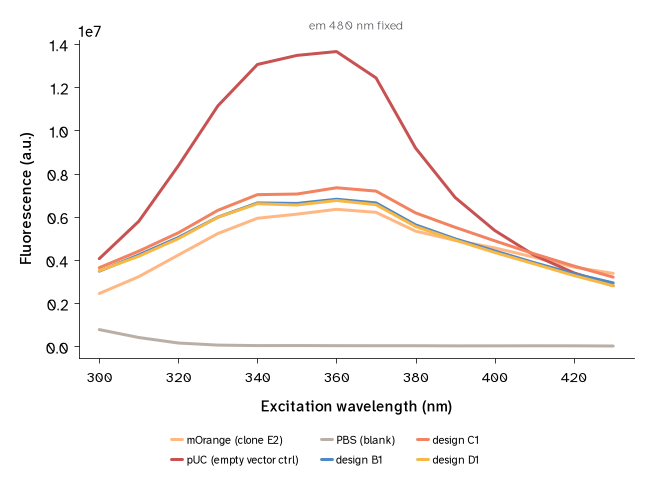

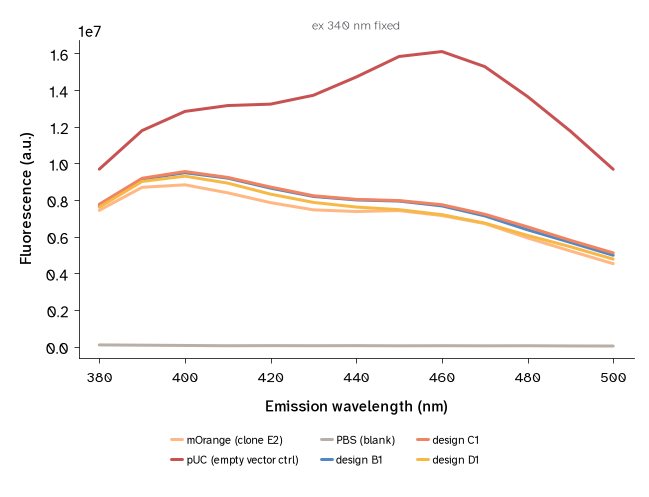

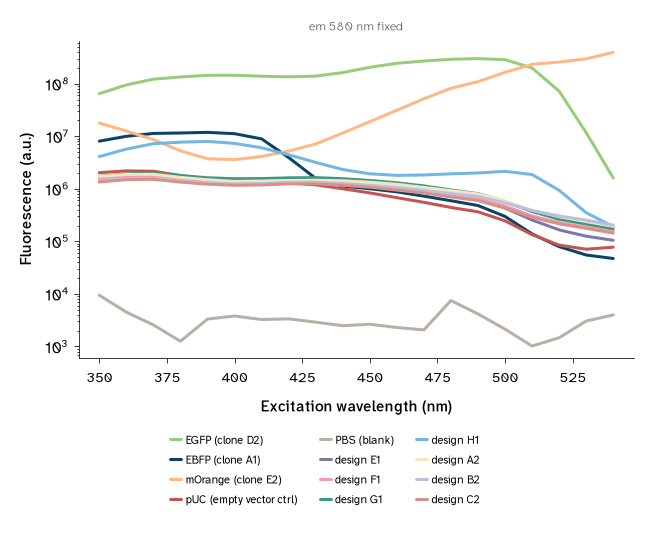

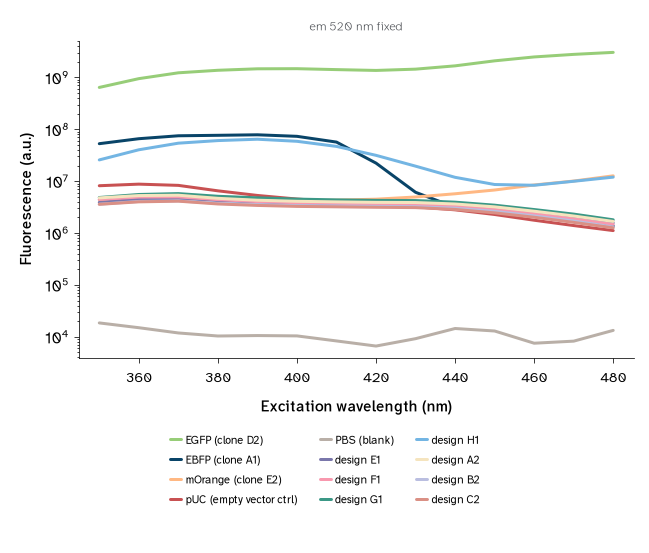

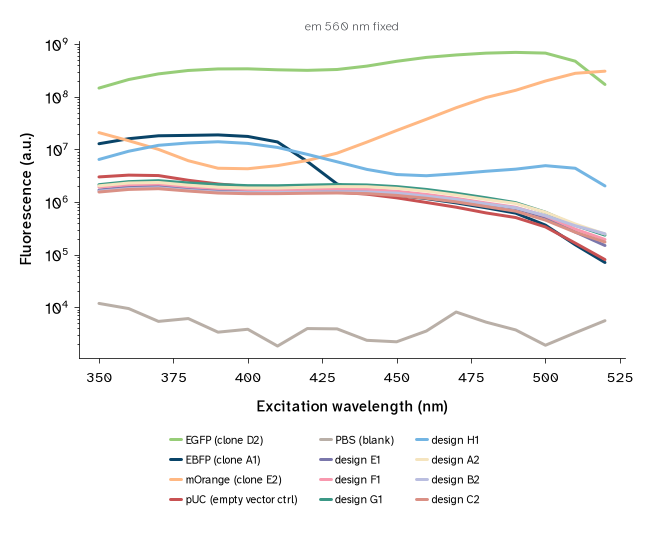

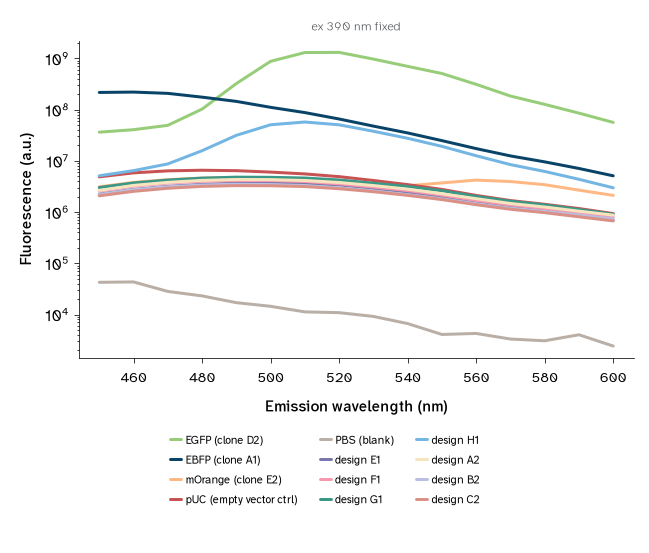

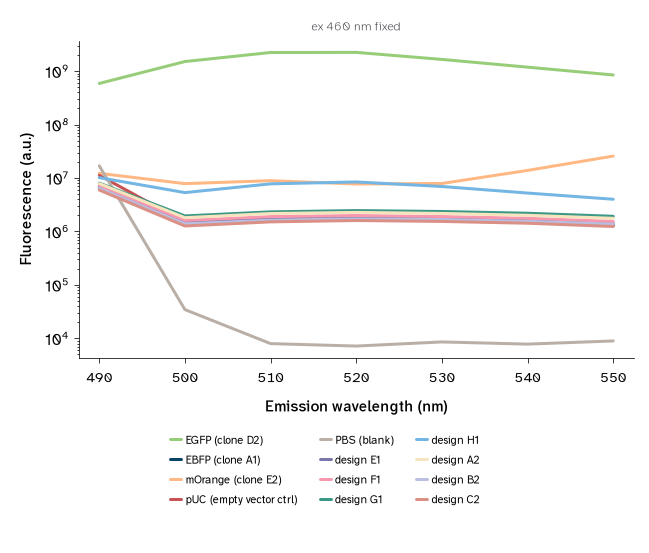

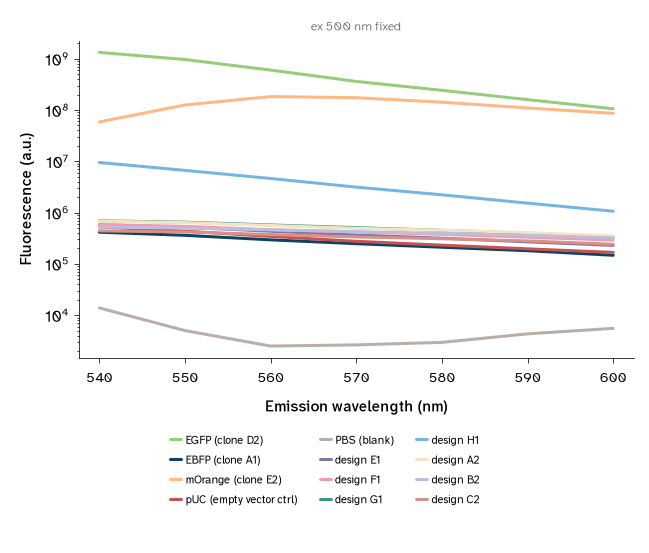

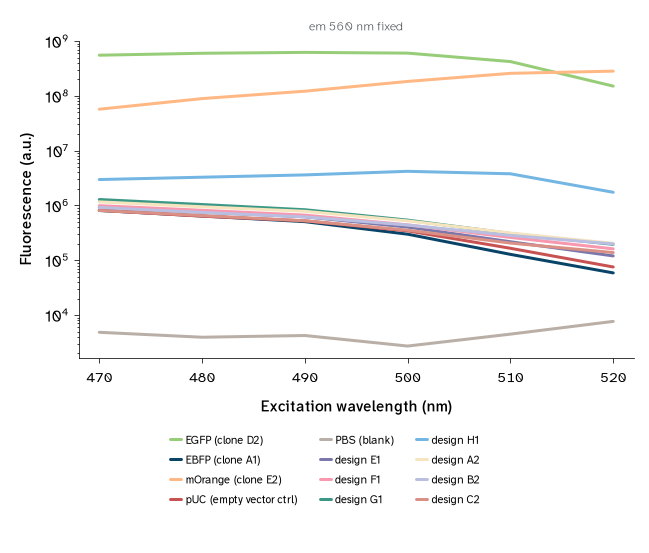

In [8]:
for w in WINDOWS:
    plate, scan_type, group = w["plate"], w["scan_type"], w["group"]
    yscale = w.get("yscale", "log")
    exclude = w.get("exclude", [])
    well_order = [label for label in WELL_ORDER_BY_GROUP[group] if label not in exclude]
    label_to_well = LABEL_TO_WELL_BY_GROUP[group]

    total_height = figure_height(len(well_order))
    fig, ax = plt.subplots(figsize=(FLOAT * PX, total_height * PX))
    ax.set_yscale(yscale)

    for label in well_order:
        well = label_to_well[label]
        wavelength, value = get_spectrum(plate, well)
        ax.plot(wavelength, value, color=ROLE_COLOR[label], lw=3, label=LEGEND_LABEL[label])

    ax.set_xlabel(AXIS_LABEL[scan_type])
    ax.set_ylabel(Y_LABEL)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    annotate_fixed_wavelength(ax, w["fixed_kind"], w["fixed_nm"])

    frac = legend_fraction(len(well_order), total_height)
    fig.tight_layout(rect=[0, frac, 1, 1])
    fig.canvas.draw()
    handles = [Line2D([0], [0], color=ROLE_COLOR[label], lw=3) for label in well_order]
    add_bottom_legend(fig, handles, [LEGEND_LABEL[label] for label in well_order], top_y=frac)
    apc.mpl.style_plot(ax, monospaced_axes="x")
    if yscale == "log":
        ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation())

    name = f"Fig{w['fig_num']}_{plate.replace(' ', '-').replace(':', '')}-{scan_type}-scan_Float"
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches=None)
    plt.show()

## OD600 dilution checks (not mapped to the fluorescence wells above)

`4x diluted 200uL` and `4x diluted 100 uL` are both single-wavelength (600 nm) endpoint reads, but
neither shares the fluorescence plates' B/C/D well layout: `4x diluted 200uL` spans rows A-C across
all 12 columns, and `4x diluted 100 uL` spans rows C-D across columns 1-8. That's a different
occupied region from row B/C/D cols 1-7 above, so there's no well-for-well correspondence to
assume here -- these are plotted as raw plate-view heatmaps (culture-density / dilution QC) rather
than used to normalize any spectrum -- which is why OD-normalization is skipped entirely here.

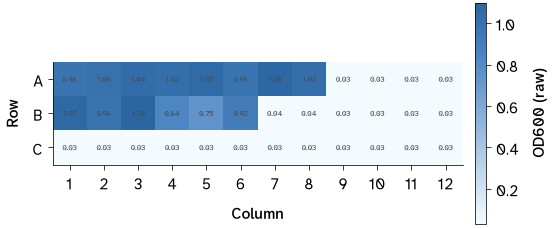

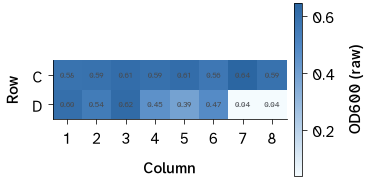

In [9]:
def plate_heatmap(plate):
    """row x column matrix of OD600 for one endpoint plate, NaN outside the wells actually read."""
    sel = raw[raw.plate_name == plate]
    rows = sorted(sel.row_label.unique())
    cols = sorted(sel.column_label.unique())
    grid = np.full((len(rows), len(cols)), np.nan)
    row_idx = {r: i for i, r in enumerate(rows)}
    col_idx = {c: i for i, c in enumerate(cols)}
    for _, r in sel.iterrows():
        grid[row_idx[r.row_label], col_idx[r.column_label]] = r.value
    return rows, cols, grid


HEATMAP_CMAP = apc.gradients.blues.reverse().to_mpl_cmap()

for fig_num, plate in zip((10, 11), OD_PLATES):
    rows, cols, grid = plate_heatmap(plate)
    cell_px = 46
    fig, ax = plt.subplots(figsize=(len(cols) * cell_px * PX, len(rows) * cell_px * PX + 90 * PX), layout="constrained")
    im = ax.imshow(grid, cmap=HEATMAP_CMAP, aspect="equal")

    for i in range(len(rows)):
        for j in range(len(cols)):
            if not np.isnan(grid[i, j]):
                ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center",
                        fontsize=8, color=str(apc.charcoal))

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    fig.colorbar(im, ax=ax, label="OD600 (raw)", fraction=0.046, pad=0.03)

    name = f"Fig{fig_num}_{plate.replace(' ', '-')}-OD600-plate-view_Float"
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches=None)
    plt.show()

## Data not used above

- The two OD600 endpoint blocks are shown as plate-view heatmaps only -- see the callout above for
  why they aren't used to normalize any spectrum here.
- No wells or wavelength ranges were dropped from the nine spectral plates; every well each block
  actually read is plotted.